<a href="https://colab.research.google.com/github/41monster/AI_Courses/blob/main/2026_Spring_NuclearAI/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 금속 다축 피로 수명 예측 — 기초 RNN 실습 (SimpleRNN)> **데이터**: Chen et al. (2024), *Scientific Data*, "A deep learning dataset for metal multiaxial fatigue life prediction"> - 논문: https://www.nature.com/articles/s41597-024-03862-4> - 데이터: Materials Cloud Archive 2024.105 (https://archive.materialscloud.org/record/2395)> - 원본 코드: https://github.com/stupid-cooh/Metal-Multiaxial-Fatigue-Life-Prediction-Using-Deep-Learning## 학습 목표1. 시계열 입력 데이터를 RNN의 표준 형식 `(batch, time_step, features)`로 정리할 수 있다2. 기초 RNN(SimpleRNN) 셀의 동작을 이해하고 직접 모델을 구성한다3. 회귀 문제(피로 수명 = 사이클 수의 log)의 평가 지표(R², RMSE, MAE)를 해석한다4. 동일 데이터로 Transformer를 학습시킨 노트북과 성능을 비교할 준비를 한다## 데이터 개요- 1,167 샘플, 40종의 금속 재료(steel, aluminum, titanium alloys 등), 48가지 loading path- **입력**: 시계열 loading path (축응력/축변형률, 전단응력/전단변형률) + 재료 물성 4개- **출력**: 피로 수명 $N_f$ (사이클 수) → 회귀 학습 시에는 $\log_{10} N_f$ 사용- 압축 파일 크기 약 1.8 MiB — 매우 작아 Drive에 그대로 두고 써도 빠름## 원자력 재료공학적 의의다축 피로(multiaxial fatigue)는 원자로 압력용기, 1차 계통 배관, 증기발생기 튜브, 핵연료 피복관 등이 받는 **복합 응력 + 반복 하중** 상황을 모사한다. 따라서 본 실습의 방법론은 원자력 구조재료의 수명 평가에 직접 응용된다.

## 0. 환경 준비**런타임 설정**: `런타임 → 런타임 유형 변경 → 하드웨어 가속기: GPU (T4)`

In [1]:
import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Google Drive 마운트

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. 데이터 압축 해제Materials Cloud에서 다운받은 zip 파일을 Drive에 올려두고, Colab 로컬에 압축 해제한다.- 다운로드 URL: https://archive.materialscloud.org/record/2395- 파일명 예: `A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction.zip` (약 1.8 MB)

In [3]:
import os

# 본인 환경에 맞게 수정
ZIP_PATH = '/content/drive/MyDrive/archives_rnn.zip'
EXTRACT_TO = '/content/data'

if not os.path.exists(EXTRACT_TO):
    !unzip -q "$ZIP_PATH" -d $EXTRACT_TO
    print('압축 해제 완료')
else:
    print('이미 풀려있음')

# 풀린 폴더 구조 확인
for root, dirs, files in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/  ({len(files)} files)')

압축 해제 완료
data/  (0 files)
  A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/  (3 files)
    All data_Stress/  (253 files)
    All data_Strain/  (914 files)


## 3. 데이터 경로 설정

In [6]:
# 실제 데이터 구조에 맞게 직접 경로 지정
# data/
# ├── All data_Strain/                    ← 변형률 제어 시계열 CSV 폴더
# ├── All data_Stress/                    ← 응력 제어 시계열 CSV 폴더
# ├── data_all_strain-controlled.csv      ← 변형률 제어 요약 (라벨 + 물성)
# ├── data_all_stress-controlled.csv      ← 응력 제어 요약 (라벨 + 물성)
# └── Specific information of the materials.xlsx

# 압축이 한 단계 더 들어가 있을 수 있으니 실제 경로 확인
!ls $EXTRACT_TO

# 본 실습은 strain-controlled 데이터로 진행
# (저주기 피로 영역에서 표준적으로 쓰이는 제어 방식)
TIMESERIES_DIR = f'{EXTRACT_TO}/A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/All data_Strain'
SUMMARY_CSV    = f'{EXTRACT_TO}/A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/data_all_strain-controlled.csv'

# 경로 확인
import os
print('\n시계열 폴더:', TIMESERIES_DIR)
print('  → 존재:', os.path.exists(TIMESERIES_DIR))
if os.path.exists(TIMESERIES_DIR):
    files = os.listdir(TIMESERIES_DIR)
    print(f'  → 파일 수: {len(files)}')
    print(f'  → 예시: {files[:3]}')

print('\n요약 CSV:', SUMMARY_CSV)
print('  → 존재:', os.path.exists(SUMMARY_CSV))

'A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction'

시계열 폴더: /content/data/A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/All data_Strain
  → 존재: True
  → 파일 수: 914
  → 예시: ['E235-2-1-0-0.0016-0.0028.csv', 'E355-0-0.0035.csv', 'X5CrNi-0.0042-0.0073.csv']

요약 CSV: /content/data/A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/data_all_strain-controlled.csv
  → 존재: True


In [8]:
import pandas as pd

# 여러 인코딩을 순서대로 시도
encodings_to_try = ['utf-8', 'cp1252', 'gbk', 'gb18030', 'latin-1', 'iso-8859-1']

summary = None
for enc in encodings_to_try:
    try:
        summary = pd.read_csv(SUMMARY_CSV, encoding=enc)
        print(f'✓ 성공! 인코딩: {enc}')
        break
    except UnicodeDecodeError:
        print(f'✗ {enc} 실패')

if summary is None:
    raise RuntimeError('어떤 인코딩도 작동하지 않음. 파일을 직접 확인 필요.')

print('\n요약 CSV 행수:', len(summary))
print('컬럼:', list(summary.columns))
summary.head()

✗ utf-8 실패
✓ 성공! 인코딩: cp1252

요약 CSV 행수: 914
컬럼: ['load', 'E(Gpa)', 'TS(Mpa)', 'ss£¨Mpa£©', 'm', 'Unnamed: 5', 'Nf(label)']


,load,E(Gpa),TS(Mpa),ss£¨Mpa£©,m,Unnamed: 5,Nf(label)
0,1Cr18Ni9T-1-0.002.csv,193.0,605.0,310.0,0.3,NaN,5.301030
1,1Cr18Ni9T-1-0.003.csv,193.0,605.0,310.0,0.3,NaN,4.093772
2,1Cr18Ni9T-1-0.004.csv,193.0,605.0,310.0,0.3,NaN,3.740363
3,1Cr18Ni9T-1-0.005.csv,193.0,605.0,310.0,0.3,NaN,3.491362
4,1Cr18Ni9T-1-0.01.csv,193.0,605.0,310.0,0.3,NaN,2.977724


## 4. 데이터 들여다보기요약 CSV와 시계열 CSV를 각각 한 번 열어본다.

In [9]:
# 시계열 CSV 하나만 열어보기
import os

ts_files = sorted(os.listdir(TIMESERIES_DIR))
print(f'시계열 파일 개수: {len(ts_files)}')
print('예시 파일:', ts_files[:5])

sample_ts = pd.read_csv(os.path.join(TIMESERIES_DIR, ts_files[0]))
print('\n첫 파일의 shape:', sample_ts.shape)
print('컬럼:', list(sample_ts.columns))
sample_ts.head()

시계열 파일 개수: 914
예시 파일: ['1045HR-0-0026.csv', '1045HR-0-0038.csv', '1045HR-0-0072.csv', '1045HR-0-0173.csv', '1045HR-0010-0020.csv']

첫 파일의 shape: (240, 8)
컬럼: ['0.0000000000 ', '0.0000000000 .1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7']


,0.0000000000,0.0000000000 .1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,0.0,0.000068,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.000136,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.000204,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.000272,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.000339,NaN,NaN,NaN,NaN,NaN,NaN


## 5. 시계열 한 개 시각화학생들이 데이터의 물리적 의미를 직관적으로 이해할 수 있도록 loading path를 그려본다.

/tmp/ipykernel_2423/4076313145.py:23: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/4076313145.py:23: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/4076313145.py:23: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/4076313145.py:23: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/4076313145.py:23: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/4076313145.py:23: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/4076313145.py:23: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  p

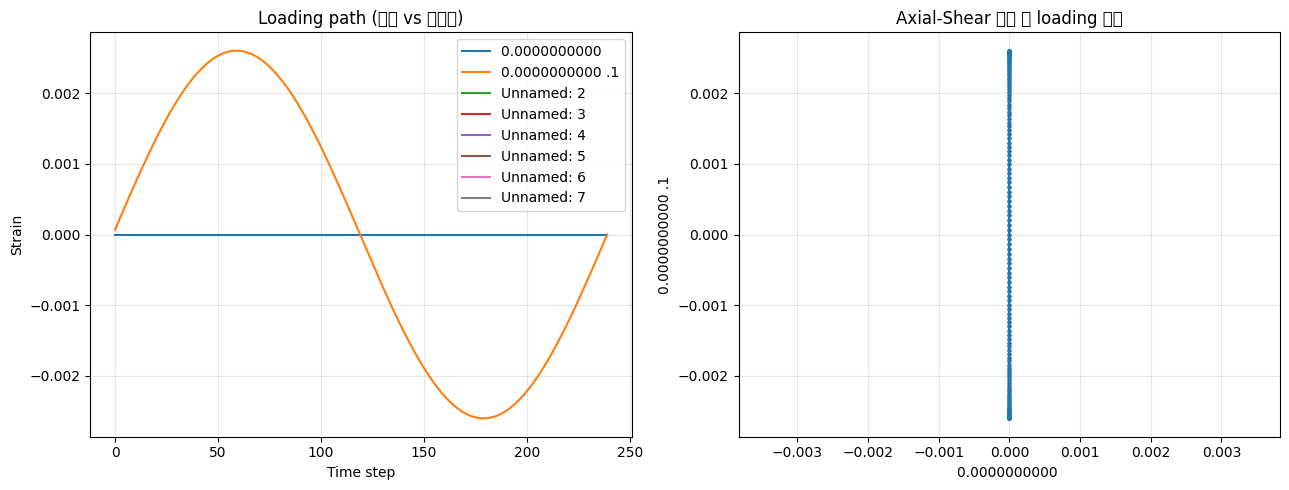

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 시간에 따른 변화
sample_ts.plot(ax=axes[0])
axes[0].set_title('Loading path (시간 vs 변형률)')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Strain')
axes[0].grid(alpha=0.3)

# 축-전단 평면에서의 궤적 (multiaxial fatigue의 핵심 시각화)
# 두 컬럼이 axial, shear strain 이라고 가정
if sample_ts.shape[1] >= 2:
    col_x, col_y = sample_ts.columns[0], sample_ts.columns[1]
    axes[1].plot(sample_ts[col_x], sample_ts[col_y], 'o-', markersize=2)
    axes[1].set_xlabel(col_x)
    axes[1].set_ylabel(col_y)
    axes[1].set_title('Axial-Shear 평면 위 loading 궤적')
    axes[1].axis('equal')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 데이터 로딩 함수요약 CSV의 각 행을 한 샘플로 확인

In [12]:
import numpy as np

# 요약 CSV에서 어떤 컬럼이 무엇인지 확인 후 본인 환경에 맞게 수정
# 일반적으로 다음 형태:
#   - 'File name' 또는 'Sample' 또는 'No.' : 시계열 파일명 또는 ID
#   - 'E' / 'Young modulus' : 탄성계수
#   - 'sigma_y' / 'Yield' : 항복강도
#   - 'sigma_u' / 'UTS'   : 인장강도
#   - 'nu' / 'Poisson'    : 푸아송비
#   - 'Nf' / 'Life'       : 피로 수명 (← 라벨)

print('요약 CSV 컬럼 전체:')
for i, c in enumerate(summary.columns):
    print(f'  [{i}] {c}')

요약 CSV 컬럼 전체:
  [0] load
  [1] E(Gpa)
  [2] TS(Mpa)
  [3] ss£¨Mpa£©
  [4] m
  [5] Unnamed: 5
  [6] Nf(label)


아래 코드에서 본인 데이터의 실제 컬럼명에 맞게 `COL_*` 변수들을 수정한다.

In [17]:
# === 본인 데이터 컬럼명에 맞게 수정 ===
COL_FILENAME = summary.columns[0]   # 시계열 파일명 컬럼 (보통 첫 번째)
COL_LIFE     = summary.columns[-1]  # 피로 수명 컬럼 (보통 마지막)
# 재료 물성 컬럼들 (4개) — 본인 데이터에서 확인 후 인덱스 조정
COLS_MATERIAL = list(summary.columns[1:5])

print(f'파일명 컬럼:  {COL_FILENAME}')
print(f'재료 물성:    {COLS_MATERIAL}')
print(f'라벨(수명):   {COL_LIFE}')

파일명 컬럼:  load
재료 물성:    ['E(Gpa)', 'TS(Mpa)', 'ss£¨Mpa£©', 'm']
라벨(수명):   Nf(label)


In [20]:
from collections import Counter

# 모든 샘플의 shape 확인
shapes = []
for idx, row in summary.iterrows():
    fname = str(row[COL_FILENAME]).strip()
    ts_path = os.path.join(TIMESERIES_DIR, fname)
    if not ts_path.endswith('.csv'):
        ts_path = ts_path + '.csv'
    if not os.path.exists(ts_path):
        continue
    ts = pd.read_csv(ts_path).values
    shapes.append(ts.shape)

shape_counts = Counter(shapes)
print('Shape 분포:')
for shape, count in shape_counts.most_common():
    print(f'  {shape}: {count}장')

Shape 분포:
  (240, 8): 808장
  (240, 2): 62장
  (240, 5): 29장
  (240, 3): 14장
  (240, 4): 1장


In [21]:
SEQ_LEN = 240  # 논문 기준 — 모든 시계열이 이미 이 길이로 통일되어 있음
N_FEATURES = 2   # 첫 2개 컬럼만 사용

X_seq_list   = []   # 시계열 입력
X_mat_list   = []   # 재료 물성 입력
y_list       = []   # 라벨

skipped = 0
length_mismatch = 0

for idx, row in summary.iterrows():
    fname = str(row[COL_FILENAME]).strip()
    # 시계열 파일 경로
    ts_path = os.path.join(TIMESERIES_DIR, fname)
    if not ts_path.endswith('.csv'):
        ts_path = ts_path + '.csv'
    if not os.path.exists(ts_path):
        skipped += 1
        continue

    ts = pd.read_csv(ts_path).values[:, :N_FEATURES]  # shape (L, num_features) #import colume 수 에러

    # 길이 검증 — 241이 아닌 파일이 있으면 건너뛰고 카운트
    if ts.shape[0] != SEQ_LEN:
        length_mismatch += 1
        continue

    X_seq_list.append(ts)
    X_mat_list.append(row[COLS_MATERIAL].values.astype(float))
    y_list.append(float(row[COL_LIFE]))

X_seq = np.array(X_seq_list, dtype=np.float32)
X_mat = np.array(X_mat_list, dtype=np.float32)
y     = np.array(y_list,     dtype=np.float32)

print(f'사용한 샘플: {len(y)}장')
print(f'누락 (파일 없음):     {skipped}장')
print(f'누락 (길이 불일치):    {length_mismatch}장')
print(f'X_seq shape: {X_seq.shape}  (samples, time_steps, features)')
print(f'X_mat shape: {X_mat.shape}  (samples, num_material_props)')
print(f'y shape    : {y.shape}')

사용한 샘플: 914장
누락 (파일 없음):     0장
누락 (길이 불일치):    0장
X_seq shape: (914, 240, 2)  (samples, time_steps, features)
X_mat shape: (914, 4)  (samples, num_material_props)
y shape    : (914,)


## 7. 라벨 변환 및 정규화피로 수명 $N_f$는 보통 $10^3$ ~ $10^7$ 사이로 매우 큰 범위에 분포한다.→ **$\log_{10} N_f$를 회귀 타깃으로** 쓰는 것이 표준이다 (수치 안정성 + 등간격 해석).

원래 N_f 범위: 2 ~ 6
log10(N_f) 범위: 0.189 ~ 0.788


/tmp/ipykernel_2423/3553439116.py:15: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/3553439116.py:15: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/3553439116.py:15: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/3553439116.py:15: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12

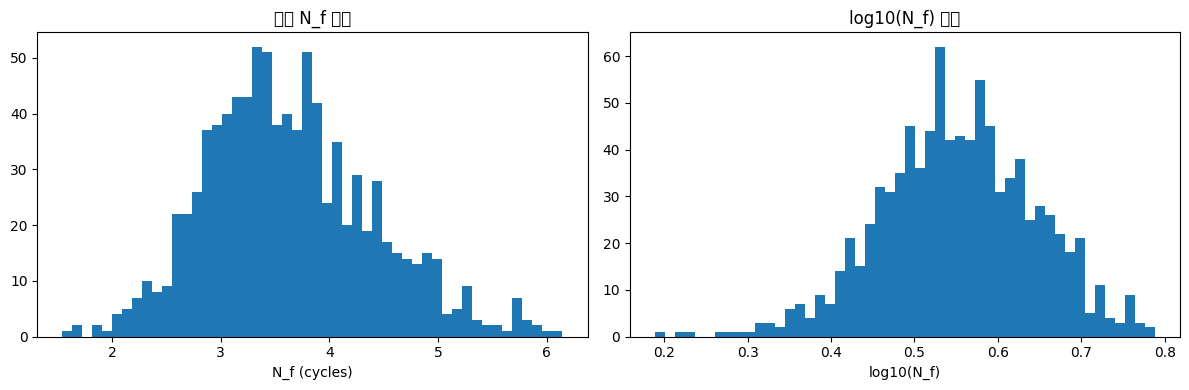

In [22]:
# 라벨을 log10으로 변환
y_log = np.log10(y)

print(f'원래 N_f 범위: {y.min():.0f} ~ {y.max():.0f}')
print(f'log10(N_f) 범위: {y_log.min():.3f} ~ {y_log.max():.3f}')

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=50)
axes[0].set_title('원래 N_f 분포')
axes[0].set_xlabel('N_f (cycles)')
axes[1].hist(y_log, bins=50)
axes[1].set_title('log10(N_f) 분포')
axes[1].set_xlabel('log10(N_f)')
plt.tight_layout()
plt.show()

## 8. Train / Validation / Test 분할 및 표준화

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 80% train, 10% val, 10% test
X_seq_tr, X_seq_te, X_mat_tr, X_mat_te, y_tr, y_te = train_test_split(
    X_seq, X_mat, y_log, test_size=0.2, random_state=42
)
X_seq_tr, X_seq_val, X_mat_tr, X_mat_val, y_tr, y_val = train_test_split(
    X_seq_tr, X_mat_tr, y_tr, test_size=0.125, random_state=42
)

print(f'Train: {len(y_tr)}, Val: {len(y_val)}, Test: {len(y_te)}')

# 시계열 표준화 — feature별로 평균/표준편차 적용
# X_seq shape (N, T, F) → (N*T, F)로 펴서 fit, 다시 (N, T, F)로 복원
N_tr, T, F = X_seq_tr.shape
scaler_seq = StandardScaler()
scaler_seq.fit(X_seq_tr.reshape(-1, F))

def scale_seq(x, scaler):
    n, t, f = x.shape
    return scaler.transform(x.reshape(-1, f)).reshape(n, t, f)

X_seq_tr  = scale_seq(X_seq_tr,  scaler_seq).astype(np.float32)
X_seq_val = scale_seq(X_seq_val, scaler_seq).astype(np.float32)
X_seq_te  = scale_seq(X_seq_te,  scaler_seq).astype(np.float32)

# 재료 물성도 표준화
scaler_mat = StandardScaler()
X_mat_tr  = scaler_mat.fit_transform(X_mat_tr).astype(np.float32)
X_mat_val = scaler_mat.transform(X_mat_val).astype(np.float32)
X_mat_te  = scaler_mat.transform(X_mat_te).astype(np.float32)

print('표준화 완료')

Train: 639, Val: 92, Test: 183
표준화 완료


## 9. SimpleRNN 모델 설계### 모델 구조 (기초 RNN)```시계열 입력 (T=50, F=feature 수)        │        ↓  SimpleRNN(32, return_sequences=True)    ← 시계열 처리        │        ↓  SimpleRNN(32)                            ← 마지막 hidden state만 출력        │        └──┐재료 물성 (4개) ──┤                   ↓              Concatenate                  ← 시계열 요약 + 재료 정보 결합                   ↓              Dense(32, relu)                   ↓              Dense(1)                     ← log10(N_f) 예측```### SimpleRNN의 작동 원리시점 $t$의 hidden state $h_t$는 다음과 같이 갱신된다:$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$- $x_t$: 시점 $t$의 입력 (이번 데이터에서는 [축변형률, 전단변형률] 등)- $h_{t-1}$: 이전 시점의 hidden state (= "기억")- $W_x, W_h$: 학습 가능한 가중치**LSTM/GRU와의 차이**: SimpleRNN은 gate 메커니즘이 없어서 장기 의존성 학습에 약하지만, 본 데이터처럼 짧은 시퀀스(T=50)에서는 충분히 잘 작동한다.

In [24]:
from tensorflow.keras import layers, models

def build_rnn_model(seq_len, n_seq_features, n_mat_features):
    # --- 시계열 입력 ---
    seq_input = layers.Input(shape=(seq_len, n_seq_features), name='timeseries_input')
    x = layers.SimpleRNN(32, return_sequences=True, activation='tanh')(seq_input)
    x = layers.SimpleRNN(32, return_sequences=False, activation='tanh')(x)

    # --- 재료 물성 입력 ---
    mat_input = layers.Input(shape=(n_mat_features,), name='material_input')

    # --- 결합 ---
    concat = layers.Concatenate()([x, mat_input])
    h = layers.Dense(32, activation='relu')(concat)
    h = layers.Dropout(0.2)(h)
    output = layers.Dense(1, name='log_Nf_output')(h)

    model = models.Model(inputs=[seq_input, mat_input], outputs=output,
                         name='SimpleRNN_FatigueModel')
    return model

n_seq_features = X_seq_tr.shape[2]
n_mat_features = X_mat_tr.shape[1]

model = build_rnn_model(SEQ_LEN, n_seq_features, n_mat_features)
model.summary()

Model: "SimpleRNN_FatigueModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ timeseries_input    │ (None, 240, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 240, 32)   │      1,120 │ timeseries_input… │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_1        │ (None, 32)        │      2,080 │ simple_rnn[0][0]  │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ material_input      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36)        │          0 │ simple_rnn_1[0][… │
│ (Concatenate)       │                   │            │ material_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_Nf_output       │ (None, 1)         │         33 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

## 10. 모델 컴파일 및 학습- **Loss**: MSE (회귀의 표준)- **Metric**: MAE (해석이 직관적 — 평균 몇 자리 log를 틀리는지)- **Optimizer**: Adam (learning rate 1e-3)

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

callbacks_list = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    [X_seq_tr, X_mat_tr], y_tr,
    validation_data=([X_seq_val, X_mat_val], y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=2
)

Epoch 1/200
20/20 - 13s - 656ms/step - loss: 0.1505 - mae: 0.3026 - val_loss: 0.0372 - val_mae: 0.1222 - learning_rate: 0.0010
Epoch 2/200
20/20 - 2s - 100ms/step - loss: 0.0602 - mae: 0.1825 - val_loss: 0.0179 - val_mae: 0.0915 - learning_rate: 0.0010
Epoch 3/200
20/20 - 1s - 65ms/step - loss: 0.0462 - mae: 0.1654 - val_loss: 0.0132 - val_mae: 0.0801 - learning_rate: 0.0010
Epoch 4/200
20/20 - 1s - 59ms/step - loss: 0.0366 - mae: 0.1453 - val_loss: 0.0093 - val_mae: 0.0745 - learning_rate: 0.0010
Epoch 5/200
20/20 - 1s - 44ms/step - loss: 0.0307 - mae: 0.1325 - val_loss: 0.0079 - val_mae: 0.0735 - learning_rate: 0.0010
Epoch 6/200
20/20 - 1s - 36ms/step - loss: 0.0246 - mae: 0.1186 - val_loss: 0.0075 - val_mae: 0.0714 - learning_rate: 0.0010
Epoch 7/200
20/20 - 1s - 35ms/step - loss: 0.0240 - mae: 0.1178 - val_loss: 0.0081 - val_mae: 0.0715 - learning_rate: 0.0010
Epoch 8/200
20/20 - 1s - 35ms/step - loss: 0.0238 - mae: 0.1144 - val_loss: 0.0077 - val_mae: 0.0721 - learning_rate: 0.00

## 11. 학습 곡선

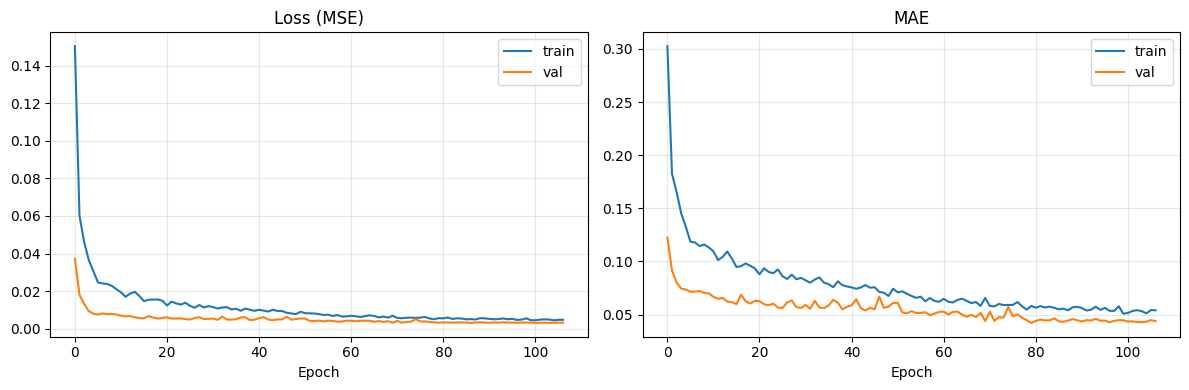

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. 테스트셋 평가

In [27]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = model.predict([X_seq_te, X_mat_te], verbose=0).ravel()

r2   = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
mae  = mean_absolute_error(y_te, y_pred)

print('=== Test 성능 (log10(N_f) 기준) ===')
print(f'R²   : {r2:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')

# 원래 cycle 수로 환원해서 비교
y_te_cycles   = 10 ** y_te
y_pred_cycles = 10 ** y_pred
print(f'\n=== Test 성능 (실제 사이클 수 기준) ===')
print(f'평균 비율 (예측/실제) : {np.mean(y_pred_cycles / y_te_cycles):.2f}')
print(f'중앙 비율             : {np.median(y_pred_cycles / y_te_cycles):.2f}')

=== Test 성능 (log10(N_f) 기준) ===
R²   : 0.5567
RMSE : 0.0640
MAE  : 0.0482

=== Test 성능 (실제 사이클 수 기준) ===
평균 비율 (예측/실제) : 0.98
중앙 비율             : 0.97


## 13. 예측 vs 실제 그래프피로 수명 예측 논문에서 표준적으로 쓰이는 시각화. 대각선에 가까울수록 좋고, 보통 **2배(factor of 2) 또는 1.5배 산점대(scatter band)** 안에 들어가면 합격.

/tmp/ipykernel_2423/3507525779.py:18: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/3507525779.py:18: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/3507525779.py:18: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2423/3507525779.py:18: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/d

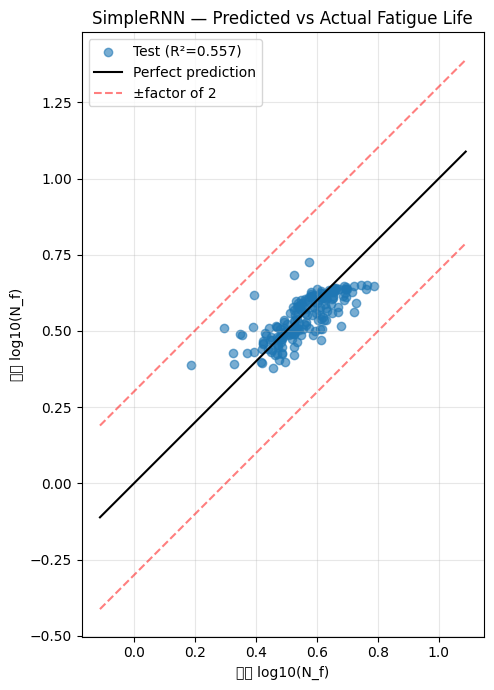

In [28]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_te, y_pred, alpha=0.6, label=f'Test (R²={r2:.3f})')

lo = min(y_te.min(), y_pred.min()) - 0.3
hi = max(y_te.max(), y_pred.max()) + 0.3
ax.plot([lo, hi], [lo, hi], 'k-', label='Perfect prediction')

# Factor of 2 (log10 기준 ±log10(2) ≈ ±0.301) 산점대
ax.plot([lo, hi], [lo + np.log10(2), hi + np.log10(2)], 'r--', alpha=0.5, label='±factor of 2')
ax.plot([lo, hi], [lo - np.log10(2), hi - np.log10(2)], 'r--', alpha=0.5)

ax.set_xlabel('실제 log10(N_f)')
ax.set_ylabel('예측 log10(N_f)')
ax.set_title('SimpleRNN — Predicted vs Actual Fatigue Life')
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 14. 결과 저장 (Transformer와의 비교를 위해)다음 노트북(Transformer)에서 같은 테스트셋으로 성능을 비교할 수 있도록 결과를 저장한다.

In [ ]:
import pickle

result = {
    'model_name': 'SimpleRNN',
    'y_test_log':    y_te.tolist(),
    'y_pred_log':    y_pred.tolist(),
    'R2':            float(r2),
    'RMSE':          float(rmse),
    'MAE':           float(mae),
    'n_params':      int(model.count_params()),
    'seq_len':       SEQ_LEN,
}

SAVE_DIR = '/content/drive/MyDrive/fatigue_rnn_results'
os.makedirs(SAVE_DIR, exist_ok=True)
with open(os.path.join(SAVE_DIR, 'simple_rnn_result.pkl'), 'wb') as f:
    pickle.dump(result, f)

# Train/val/test 분할도 같은 분할을 재현할 수 있도록 random_state를 메모
print(f'저장 완료: {SAVE_DIR}/simple_rnn_result.pkl')
print(f'파라미터 수: {model.count_params():,}')

---## 학생 토의 과제1. **SimpleRNN의 한계**: 본 데이터는 시퀀스 길이가 50으로 짧지만, 만약 500, 5000이라면 SimpleRNN이 어떻게 될까? "vanishing gradient" 개념과 연관지어 설명하라.2. **재료 물성 입력의 효과**: 재료 물성(`X_mat`)을 제거하고 시계열만으로 학습하면 R²가 얼마나 떨어지는가?3. **시퀀스 길이의 영향**: `SEQ_LEN`을 20, 100, 200으로 바꿔가며 성능을 비교하라.4. **Hidden unit 수**: SimpleRNN의 unit을 16, 64, 128로 바꾸면 어떻게 되는가?5. **다음 단계**: Transformer 노트북을 실행해서 동일 조건에서 성능을 비교하라. RNN과 Transformer의 차이가 어디서 나오는가?## 다음 노트북같은 데이터로 Transformer encoder를 학습하는 노트북(`fatigue_transformer_colab.ipynb`)을 이어서 실행하세요.